# COSC2753 Assignment 2 — Fashion Intelligence System
# Task 2 — `season` Classification

**Prerequisite: run `COSC2753_A2_Preprocessing.ipynb` first.** This notebook loads the
artifacts that notebook writes to `../data/processed/` rather than repeating the cleaning,
splitting and encoding itself.

Loading rather than re-running matters for correctness, not just speed. Every notebook that
re-derives the split gets its own `StratifiedGroupKFold` draw, so a row could sit in train
here and validation there — and any score compared across notebooks would be measured
against a different validation set. Reading one saved split guarantees all four notebooks
mean the same thing by "validation".


## Part I — Load the preprocessed data

**MODIFY — this replaces the full preprocessing pipeline that used to be inlined here.**
The eighty-odd cells of Part I/II have been reduced to the three cells below, which read
what `COSC2753_A2_Preprocessing.ipynb` already computed and saved.

### What is loaded, and what is rebuilt

Loaded straight from disk:

| Artifact | File |
|---|---|
| Full cleaned train/validation split | `train_full.csv`, `val_full.csv` |
| Per-task usable subsets (target non-null, encoded) | `holdout_metadata/{target}_{train,val}.csv` |
| Fitted `LabelEncoder` per target | `label_encoders.pkl` |
| Image size, normalisation constants, thresholds, seed | `pipeline_config.json` |

Rebuilt in code, because they are not serialisable objects:

- **`train_transform` / `eval_transform`** — torchvision transforms hold a lambda-free but
  still unpicklable graph. They are reconstructed from the `normalization_mean` and
  `normalization_std` recorded in `pipeline_config.json`, so they are numerically identical
  to the ones used to compute those statistics, not merely similar.
- **`FashionImageDataset`, `get_weighted_sampler`** — ordinary class and function definitions.

### The one thing to watch

`id` is read back with `dtype=str`. Left to infer, pandas returns `int64`, and while
`f"{52003}.jpg"` happens to build a valid filename, an integer `id` breaks every
`set(...) & set(...)` leakage check against a string-keyed id set — silently, by finding no
overlap where overlap exists. The explicit dtype is what keeps those checks meaningful.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8508, 0.8336, 0.8284], std [0.2709, 0.2829, 0.2858]
Rare-class thresholds: articleType>=20, usage>=100


In [2]:
# dtype={'id': str} is load-bearing -- see the note above.
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

# `target_columns` maps a task name to the column actually predicted, which is NOT always
# the task name: rare-class grouping means articleType -> articleType_grouped and
# usage -> usage_grouped. Rebuilt by inspecting the saved files rather than hardcoded, so
# it cannot drift out of step with what preprocessing produced.
target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

# The main split partitions the cleaned dataset exactly, so `df` is recoverable by
# concatenation. Task 2's season split is a separate draw from the same rows (Section
# II.4.1) and is already reflected in the season_* holdout files, so it needs nothing here.
df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28958, 13)   val_full: (9653, 13)   combined: (38611, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28958  val=  9648  classes= 92
  season       -> column season               train= 28943  val=  9648  classes=  4
  gender       -> column gender               train= 28958  val=  9653  classes=  5
  usage        -> column usage_grouped        train= 28902  val=  9637  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: conservative augmentation only. These are catalog product photos, so a
# vertical flip or a large rotation would produce an item that never occurs in the data.
# fill=255 because the backgrounds are white -- the default fill=0 would paste black wedges
# into every rotated corner and teach the model an artefact absent at evaluation time.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
    data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
    dtype=torch.double)
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler above, not by
# weighting the loss -- applying both would double-count the correction.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1164 -> tensor (3, 80, 60), range [-3.00, 0.60]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II — Task 2

Everything below is unchanged. It now runs against the loaded split instead of a locally recomputed one.

## Task 2: Fashion season classification

In [4]:
# Reuse the Task 2-specific prepared splits. These already contain season_enc.
task2_train = train_usable['season'].copy()
task2_val = val_usable['season'].copy()

assert 'season_enc' in task2_train.columns
assert 'season_enc' in task2_val.columns
print(f'Task 2 train: {len(task2_train):,}; validation: {len(task2_val):,}')
print('Season classes:', encoders['season'].classes_.tolist())

Task 2 train: 28,943; validation: 9,648
Season classes: ['Fall', 'Spring', 'Summer', 'Winter']


In [5]:
print(task2_train.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'season_enc']


### a) Tabular data preprocessing

Image preprocessing will be the same as task 1  
Metadata needs to be pre-processed since it was used in multi-input models. For categorical attributes, missing values will be imputed using mode. Then the data will be encoded using one-hot encoder [REFERENCE HERE]. On the other hand, numerical data will go through median imputation because it’s resistant to outliers [REFERNCE HERE] and then scaled using sklearn StandardScaler. The target attribute “season” had 13 missing values and will be dropped instead of imputed. This was done to make sure no artificial bias will be introduced into the dataset. The target attribute is then encoded to numerical label so machine learning models can predict them.  


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
# MODIFY: f1_score/accuracy_score are no longer imported by the corrected
# preprocessing (they were unused there); Task 2 needs them, so import here.
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import joblib

TASK2_TARGET = 'season'
META_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
META_CAT = [c for c in META_FEATURES if c != 'year']
META_NUM = ['year']

# MODIFY: these four lines were no-ops. train_usable/val_usable['season'] were
# already filtered to non-null season in Section II.4 and already had unseen-label
# rows dropped at the encoder step in Section II.5. Kept as assertions instead, so
# the guarantee is still checked but the rows aren't silently re-filtered twice.
assert task2_train[TASK2_TARGET].notna().all() and task2_val[TASK2_TARGET].notna().all()
assert set(task2_val[TASK2_TARGET]).issubset(set(task2_train[TASK2_TARGET]))

X_train = task2_train[META_FEATURES].copy()
X_val = task2_val[META_FEATURES].copy()
# Convert pandas nullable values to NumPy-compatible missing values for sklearn.
for frame in (X_train, X_val):
    for col in META_CAT:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')

# Single preprocessor shared by BOTH the tabular baseline and the multi-input deep model,
# so there's one source of truth for how metadata gets encoded.
meta_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM)
])
meta_train = meta_preprocessor.fit_transform(X_train).astype('float32')
meta_val = meta_preprocessor.transform(X_val).astype('float32')

# Reuse the season encoder already fit in Section 6.5 -- no need for a second one.
season_encoder = encoders['season']
y_train = task2_train['season_enc'].to_numpy()
y_val = task2_val['season_enc'].to_numpy()

print('Metadata train shape:', meta_train.shape)
print('Metadata validation shape:', meta_val.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

Metadata train shape: (28943, 225)
Metadata validation shape: (9648, 225)
Encoded target shapes: (28943,) (9648,)


The preprocessing step was compiled into a sklearn Pipeline to ensure that we can use them for train split with .fit_transform() and validation split with .transform(). This ensure that no data leakage will appear during the pre-processing step. To deal with imbalanced classes, WeightedRandomSampler was used during training to ensure batches are more balanced across classes.

### b) Model choice and comparison:
#### 1. Baseline model testing:

Before implementing multi-input models, we train and test two baseline models, one for each type of datatype. We used Logistic Regression to predict using only metadata due to its simplicity while maintaining a fair baseline performance [REFERENCE HERE]. ResNet18 was used for image-only data of dataset because it have high accuracy while still being lightweight and fast [REFERENCE HERE].

Logistic Regression (metadata only) -- train F1: 0.7322, val F1: 0.7357

              precision    recall  f1-score   support

        Fall       0.65      0.89      0.75      2628
      Spring       0.48      0.78      0.60       392
      Summer       0.88      0.64      0.74      4784
      Winter       0.83      0.88      0.85      1844

    accuracy                           0.76      9648
   macro avg       0.71      0.80      0.74      9648
weighted avg       0.79      0.76      0.76      9648



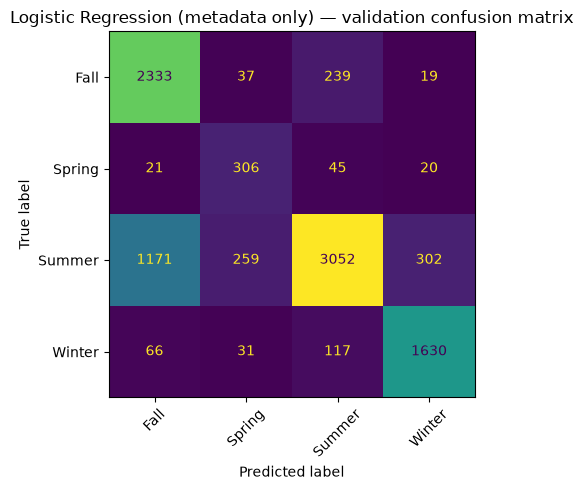

Saved metadata-only baseline to ../data/processed/task2_models


In [7]:
# Metadata-only baseline: how far do tabular features alone get us on season prediction,
# before we spend effort on the image branch at all?
BASELINE_DIR = OUT_DIR / 'task2_models'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(meta_train, y_train)

logreg_train_f1 = f1_score(y_train, logreg.predict(meta_train), average='macro')
logreg_val_pred = logreg.predict(meta_val)
logreg_val_f1 = f1_score(y_val, logreg_val_pred, average='macro')

print(f'Logistic Regression (metadata only) -- train F1: {logreg_train_f1:.4f}, val F1: {logreg_val_f1:.4f}\n')
print(classification_report(y_val, logreg_val_pred, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, logreg_val_pred, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Logistic Regression (metadata only) — validation confusion matrix')
plt.tight_layout()
plt.show()

joblib.dump(logreg, BASELINE_DIR / 'logreg_metadata_baseline.joblib')
print(f'Saved metadata-only baseline to {BASELINE_DIR}')

#### 1a. Ablation: does `productDisplayName` or `year` affect metadata-only prediction?

The baseline here includes every metadata field available, including `year` and a TF-IDF representation of the free-text `productDisplayName` field. From that full baseline, we remove `year`, then `productDisplayName`, then both together, to isolate what each one is actually contributing to `season` prediction. Random Forest is used here instead of Logistic Regression, since it handles the mixed one-hot/TF-IDF/numeric feature space without needing feature scaling, and can pick up non-linear interactions between fields that a linear model can't.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

def build_metadata_matrix(train_df, val_df, use_year=True, use_text=False, text_max_features=300):
    """Rebuild the metadata design matrix with year and/or productDisplayName toggled on/off,
    reusing the same imputation/encoding strategy as the main meta_preprocessor above."""
    cat_features = list(META_CAT)  # gender, masterCategory, subCategory, articleType, baseColour, usage
    num_features = ['year'] if use_year else []
    text_col = ['productDisplayName'] if use_text else []

    transformers = [
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
    if num_features:
        transformers.append((
            'num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())
            ]), num_features
        ))
    if use_text:
        # 'productDisplayName' as a bare string (not a list) makes ColumnTransformer pass a
        # 1D array to TfidfVectorizer, which is what it expects.
        transformers.append(('text', TfidfVectorizer(max_features=text_max_features, stop_words='english'),
                              'productDisplayName'))

    preprocessor = ColumnTransformer(transformers)

    cols = cat_features + num_features + text_col
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    for col in cat_features:
        Xtr[col] = Xtr[col].astype(object).where(Xtr[col].notna(), np.nan)
        Xva[col] = Xva[col].astype(object).where(Xva[col].notna(), np.nan)
    for col in num_features:
        Xtr[col] = pd.to_numeric(Xtr[col], errors='coerce')
        Xva[col] = pd.to_numeric(Xva[col], errors='coerce')
    for col in text_col:
        Xtr[col] = Xtr[col].astype(object).fillna('Unknown')
        Xva[col] = Xva[col].astype(object).fillna('Unknown')

    Mtr = preprocessor.fit_transform(Xtr).astype('float32')
    Mva = preprocessor.transform(Xva).astype('float32')
    return Mtr, Mva


def run_rf_ablation(name, train_matrix, val_matrix):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_train)
    train_f1 = f1_score(y_train, model.predict(train_matrix), average='macro')
    val_f1 = f1_score(y_val, model.predict(val_matrix), average='macro')
    print(f'{name:42s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1


ablation_results = {}

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=True, use_text=True)
ablation_results['Baseline'] = run_rf_ablation('Baseline', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=False, use_text=True)
ablation_results['Without year'] = run_rf_ablation('Without year', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=True, use_text=False)
ablation_results['Without productDisplayName'] = run_rf_ablation('Without productDisplayName', m_tr, m_va)

m_tr, m_va = build_metadata_matrix(task2_train, task2_val, use_year=False, use_text=False)
ablation_results['Without year, without productDisplayName'] = run_rf_ablation(
    'Without year, without productDisplayName', m_tr, m_va)

ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
display(ablation_df.round(4))


Baseline                                   train F1: 0.9603  val F1: 0.8690
Without year                               train F1: 0.8793  val F1: 0.7616
Without productDisplayName                 train F1: 0.8198  val F1: 0.7847
Without year, without productDisplayName   train F1: 0.6222  val F1: 0.5810


,Train F1,Validation F1
Baseline,0.9603,0.8690
Without year,0.8793,0.7616
Without productDisplayName,0.8198,0.7847
"Without year, without productDisplayName",0.6222,0.5810


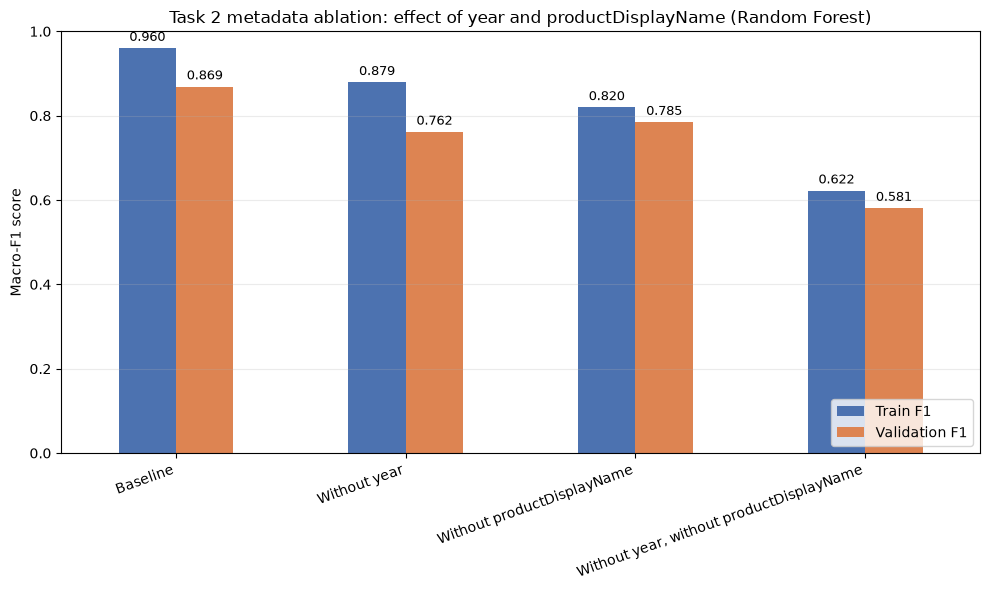

In [9]:
ax = ablation_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score')
plt.title('Task 2 metadata ablation: effect of year and productDisplayName (Random Forest)')
plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


In [10]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights, efficientnet_b0
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 70, 6

sampler = get_weighted_sampler(task2_train, 'season')

class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model

class MultiInputDataset(Dataset):
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame, self.metadata, self.labels = frame.reset_index(drop=True), metadata, labels
        self.image_dir, self.transform = image_dir, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            image = self.transform(im)
        return image, torch.tensor(self.metadata[i].toarray() if hasattr(self.metadata[i], 'toarray') else self.metadata[i], dtype=torch.float32).squeeze(0), torch.tensor(self.labels[i], dtype=torch.long)

# Build datasets and loaders for the multi-input model.
train_ds = MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, train_transform)
val_ds = MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                           persistent_workers=(NUM_WORKERS > 0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         persistent_workers=(NUM_WORKERS > 0))

# Shared loaders for the two image-only comparison models (built once, reused for both
# ResNet18 and MobileNetV3 so workers aren't spun up and torn down twice).
train_ds_img = FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', train_transform)
train_loader_img = DataLoader(train_ds_img, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))
val_loader_img = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
                            batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))

# Create pretrained image-only comparison models and replace their classifiers for season prediction.
def make_pretrained(model_name):
    if model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(season_encoder.classes_))
    else:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(season_encoder.classes_))
    return model.to(DEVICE)

class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor for MultiInputNet --
    the missing cell of the 2x2 grid: pretrained encoder WITH metadata."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class SmallImageEncoder(nn.Module):
    """From-scratch CNN sized for 60x80 images — no aggressive early downsampling."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 60x80 -> 30x40

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 30x40 -> 15x20

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.out_dim = out_dim
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.proj(self.features(x).flatten(1))

class ResNet18Encoder(nn.Module):
    """From-scratch ResNet18 backbone, weights=None — kept as a comparison point
    against SmallImageEncoder to show whether stem downsampling hurts at 60x80."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        self.out_dim = out_dim
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class EfficientNetEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = efficientnet_b0(weights=None)

        self.out_dim = out_dim
        # Replace classifier with Identity to get raw backbone features (1280-dim)
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        
        # Project directly from 1280 features to out_dim (128)
        self.proj = nn.Linear(1280, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))

class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut matching if channels change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections, SiLU activations, 
    and gradual spatial downsampling for 60x80 images."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        
        self.stage1 = ConvBlock(3, 32)
        self.pool1  = nn.MaxPool2d(2)                            # 60x80 -> 30x40
        
        self.stage2 = ConvBlock(32, 64)
        self.pool2  = nn.MaxPool2d(2)                            # 30x40 -> 15x20
        
        self.stage3 = ConvBlock(64, 128)
        self.pool3  = nn.MaxPool2d(2)                            # 15x20 -> 7x10
        
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)               # 7x10  -> 1x1
        
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.SiLU()
        )

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        x = self.stage4(x)
        
        x = self.global_pool(x).flatten(1)
        return self.proj(x)

# MODIFY: new from-scratch architecture -- see the markdown cell in section 1d.
# No torchvision backbone and no `weights=` argument, so it stays fully self-trained.
import torch.nn.functional as F


class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualEncoder(nn.Module):
    """From-scratch SE-residual encoder sized for 60x80 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8. Unlike ResNet18Encoder there is no
    stride-2 stem or stem max-pool, so no spatial detail is discarded up front."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


class MultiInputNet(nn.Module):
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        image_dim = image_encoder.out_dim
        self.meta_scale = nn.Parameter(torch.tensor(1.0))
        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        
    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata) * self.meta_scale
        fused = torch.cat([img_feats, meta_feats], dim=1)
        return self.head(fused)

In [11]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def to_device(batch):
    """Both loaders end with the label; everything before it is model input.
    (image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata].
    This one line is what lets train_model and train_image_only collapse into one function."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    """One pass over `loader`. Training if `optimiser` is given, eval-only otherwise."""
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)

            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro')


def fit(model, loader_tr, loader_va, model_name='model', patience=15, lr=3e-4, weight_decay=1e-4):
    """Replaces train_model and train_image_only. Same optimiser settings for every
    model (train_image_only used to skip weight_decay -- that was an accident of
    copy-paste, not a deliberate choice, so it's gone now)."""
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = None
    best_val_loss = None
    best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch + 1}/{EPOCHS}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch + 1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {current_lr:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)

    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch}  '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')

    return model, best_val_f1, best_epoch


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            
            # Keep predictions and labels on GPU as tensors
            preds = model(*inputs).argmax(dim=1)
            
            all_preds.append(preds)
            all_actual.append(labels)
            
    # Concatenate directly on GPU, then transfer to CPU ONCE
    preds_np = torch.cat(all_preds).cpu().numpy()
    actual_np = torch.cat(all_actual).cpu().numpy()
    
    return f1_score(actual_np, preds_np, average='macro')


ResNet18 (pretrained) 1/70 train:   0%|          | 0/453 [00:01<?, ?it/s]

ResNet18 (pretrained) 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8004 - val_loss: 0.8466 - train_f1: 0.6548 - val_f1: 0.5983 - lr: 3.00e-04


ResNet18 (pretrained) 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet18 (pretrained) 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

ResNet18 (pretrained) 23/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 23/70 - train_loss: 0.0815 - val_loss: 0.9829 - train_f1: 0.9699 - val_f1: 0.7732 - lr: 1.87e-05


ResNet18 (pretrained) 24/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet18 (pretrained) 24/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 24/70 - train_loss: 0.0730 - val_loss: 1.0023 - train_f1: 0.9733 - val_f1: 0.7724 - lr: 1.87e-05
Early stopping triggered at epoch 24 (best epoch was 9)


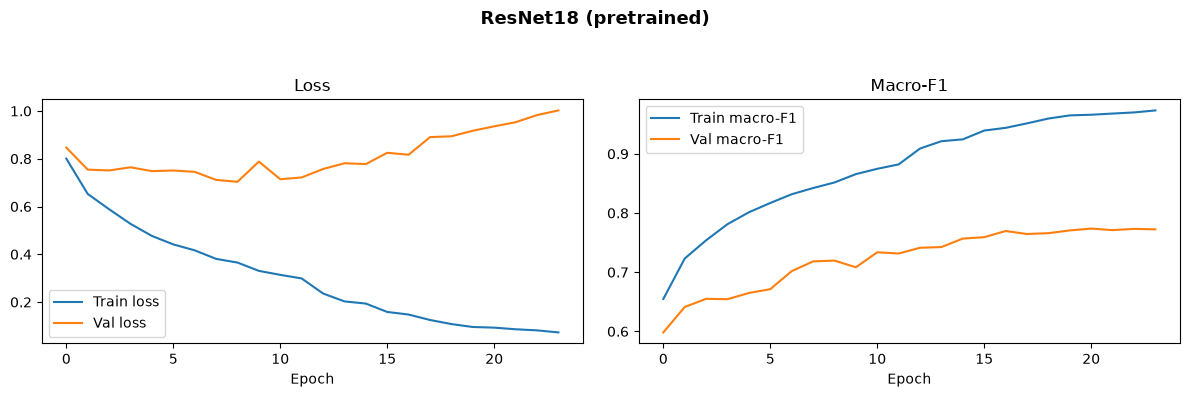

>>> Best checkpoint for ResNet18 (pretrained): epoch 9  (val_loss=0.7036, val_f1=0.7196)


In [12]:
OUTPUT_DIR = Path('../outputs') / 'task2_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(RANDOM_STATE)
results = {}
resnet_model, resnet_f1, resnet_epoch = fit(
    make_pretrained('resnet18'), train_loader_img, val_loader_img, model_name='ResNet18 (pretrained)')
results['ResNet18 (pretrained)'] = (resnet_f1, resnet_epoch)

ResNet18 (pretrained, image only) -- train F1: 0.8367, val F1: 0.7196

              precision    recall  f1-score   support

        Fall       0.71      0.65      0.68      2628
      Spring       0.60      0.76      0.67       392
      Summer       0.77      0.79      0.78      4784
      Winter       0.74      0.75      0.74      1844

    accuracy                           0.74      9648
   macro avg       0.71      0.74      0.72      9648
weighted avg       0.74      0.74      0.74      9648



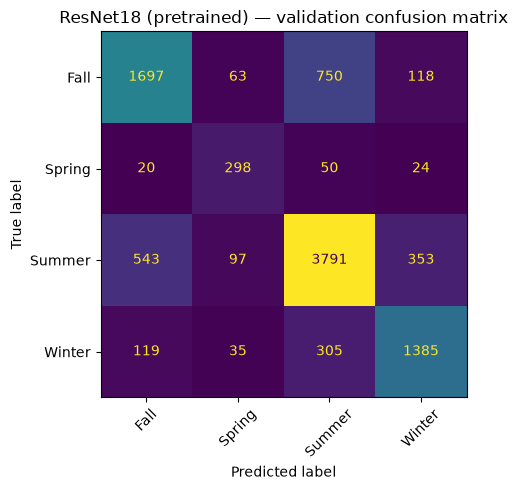

In [13]:
# Testing: ResNet18 (pretrained, image-only) -- same treatment as the metadata-only
# baseline above (val F1, classification report, confusion matrix), so both baselines
# are fully tested here before we move on to the multi-input models.
image_train_loader = DataLoader(
    FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
image_val_loader = DataLoader(
    FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

resnet_train_f1 = evaluate(resnet_model, image_train_loader)

resnet_model.eval()
resnet_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = resnet_model(images).argmax(dim=1).cpu().numpy()
        resnet_val_preds.extend(preds)
resnet_val_preds = np.array(resnet_val_preds)
resnet_val_f1 = f1_score(y_val, resnet_val_preds, average='macro')

print(f'ResNet18 (pretrained, image only) -- train F1: {resnet_train_f1:.4f}, val F1: {resnet_val_f1:.4f}\n')
print(classification_report(y_val, resnet_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, resnet_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ResNet18 (pretrained) — validation confusion matrix')
plt.tight_layout()
plt.show()


#### 1c. ImprovedSmallCNN (image-only)

`styles_prediction.csv` (the real test set) has no metadata at all, so the multi-input model can't run on it directly -- `MultiInputNet` requires both an image and a metadata vector. This image-only version of our chosen encoder (`ImprovedSmallImageEncoder`) is what we actually use for test-set predictions. It's trained and tested here, alongside the other image-only/metadata-only baselines, before the multi-input section.

ImprovedSmallCNN (image-only) 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9696 - val_loss: 0.9679 - train_f1: 0.5608 - val_f1: 0.5207 - lr: 3.00e-04


ImprovedSmallCNN (image-only) 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

ImprovedSmallCNN (image-only) 33/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 33/70 - train_loss: 0.3271 - val_loss: 0.6891 - train_f1: 0.8669 - val_f1: 0.7280 - lr: 2.34e-06


ImprovedSmallCNN (image-only) 34/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 34/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 34/70 - train_loss: 0.3220 - val_loss: 0.6851 - train_f1: 0.8682 - val_f1: 0.7265 - lr: 2.34e-06
Early stopping triggered at epoch 34 (best epoch was 19)


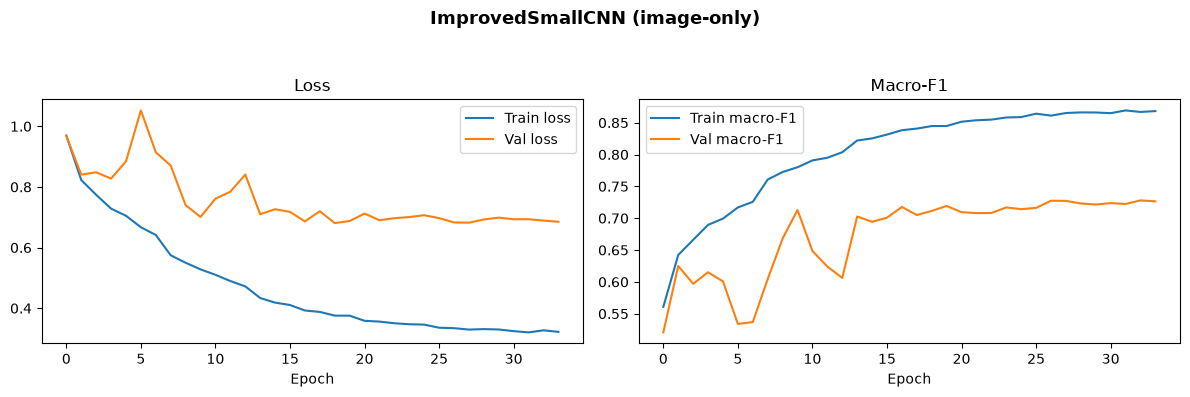

>>> Best checkpoint for ImprovedSmallCNN (image-only): epoch 19  (val_loss=0.6808, val_f1=0.7114)


In [14]:
class ImageOnlyClassifier(nn.Module):
    """An encoder plus a plain linear head -- no metadata branch. Used to get a
    working model for images with no metadata, e.g. the real test set."""
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
improved_small_cnn_img_only_model, improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch = fit(
    ImageOnlyClassifier(ImprovedSmallImageEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='ImprovedSmallCNN (image-only)')
results['ImprovedSmallCNN (image-only)'] = (improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch)


ImprovedSmallCNN (image only) -- train F1: 0.8307, val F1: 0.7114

              precision    recall  f1-score   support

        Fall       0.67      0.73      0.70      2628
      Spring       0.61      0.74      0.67       392
      Summer       0.81      0.69      0.75      4784
      Winter       0.67      0.81      0.73      1844

    accuracy                           0.73      9648
   macro avg       0.69      0.74      0.71      9648
weighted avg       0.74      0.73      0.73      9648



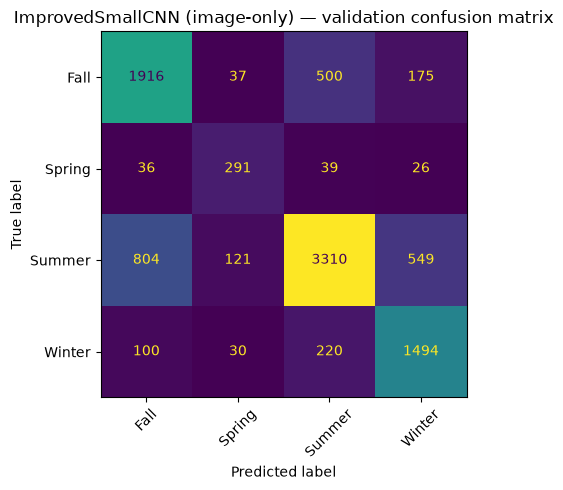

Saved ImprovedSmallCNN (image-only) to ../outputs/task2_models/improved_small_cnn_image_only.pt


In [15]:
# Testing: ImprovedSmallCNN (image-only) -- same treatment as the other baselines above.
improved_small_cnn_img_only_train_f1 = evaluate(improved_small_cnn_img_only_model, image_train_loader)

improved_small_cnn_img_only_model.eval()
improved_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = improved_small_cnn_img_only_model(images).argmax(dim=1).cpu().numpy()
        improved_img_only_val_preds.extend(preds)
improved_img_only_val_preds = np.array(improved_img_only_val_preds)
improved_small_cnn_img_only_val_f1 = f1_score(y_val, improved_img_only_val_preds, average='macro')

print(f'ImprovedSmallCNN (image only) -- train F1: {improved_small_cnn_img_only_train_f1:.4f}, '
      f'val F1: {improved_small_cnn_img_only_val_f1:.4f}\n')
print(classification_report(y_val, improved_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, improved_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ImprovedSmallCNN (image-only) — validation confusion matrix')
plt.tight_layout()
plt.show()

# Saved separately since this (not the multi-input model) is what's actually used for
# the metadata-free test set.
torch.save({
    'model_state_dict': improved_small_cnn_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': improved_small_cnn_img_only_val_f1,
}, OUTPUT_DIR / 'improved_small_cnn_image_only.pt')
print(f'Saved ImprovedSmallCNN (image-only) to {OUTPUT_DIR / "improved_small_cnn_image_only.pt"}')


#### 1d. SE-Residual CNN — a stronger from-scratch encoder

**Why this should beat the models above, and why it is still from scratch.**
Every layer is randomly initialised — `weights=None` nowhere required, because none of
this comes from torchvision. Three concrete changes over the previous best:

1. **No stem downsampling.** `resnet18` opens with a 7×7 stride-2 convolution followed by
   a stride-2 max-pool, which takes an 80×60 image down to 20×15 before the first residual
   block ever runs. That design is for 224×224 inputs. Here it throws away most of the
   spatial detail up front — and at this resolution the difference between a shirt and a
   kurta is exactly that detail. This encoder starts with a stride-1 3×3 stem and
   downsamples gradually.
2. **Squeeze-excite gating.** Each block learns which of its own channels matter for the
   current image and rescales them. Cheap in parameters, and it helps most when classes
   differ by which cues are relevant rather than by their overall shape.
3. **Pre-activation ordering** (BN → SiLU → conv, with an identity skip path), which trains
   more stably at depth than the post-activation blocks used earlier.

Trained twice below, so it can be compared fairly against both families already in this notebook: once image-only (the configuration that can actually run on `styles_prediction.csv`), and once inside `MultiInputNet` in section 2.

SEResidualCNN (image-only) 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

SEResidualCNN (image-only) 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 1.0519 - val_loss: 1.0257 - train_f1: 0.5173 - val_f1: 0.4855 - lr: 3.00e-04


SEResidualCNN (image-only) 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

SEResidualCNN (image-only) 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

SEResidualCNN (image-only) 32/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 32/70 - train_loss: 0.3100 - val_loss: 0.7418 - train_f1: 0.8705 - val_f1: 0.7316 - lr: 1.87e-05


SEResidualCNN (image-only) 33/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

SEResidualCNN (image-only) 33/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 33/70 - train_loss: 0.3065 - val_loss: 0.7530 - train_f1: 0.8709 - val_f1: 0.7274 - lr: 1.87e-05
Early stopping triggered at epoch 33 (best epoch was 18)


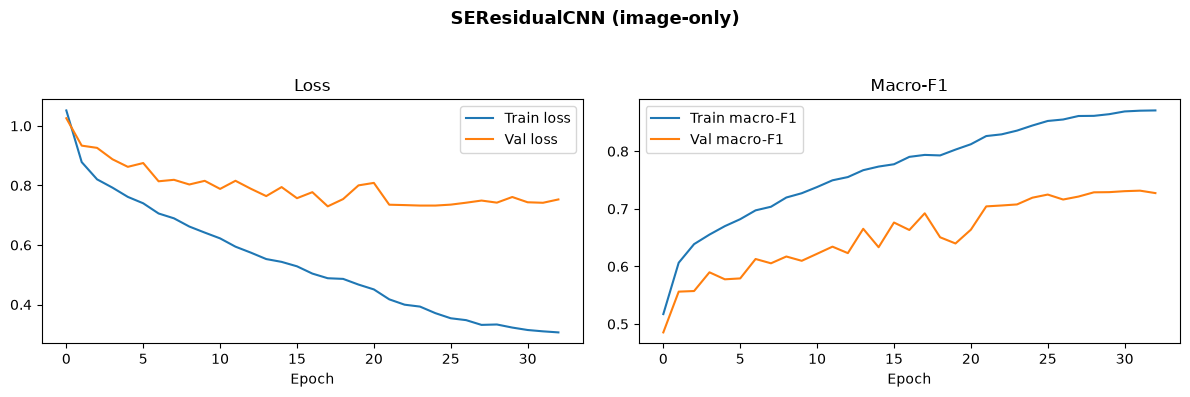

>>> Best checkpoint for SEResidualCNN (image-only): epoch 18  (val_loss=0.7298, val_f1=0.6923)
SEResidualCNN (image only) -- train F1: 0.7810, val F1: 0.6923, 2.87M params

              precision    recall  f1-score   support

        Fall       0.67      0.61      0.64      2628
      Spring       0.66      0.70      0.68       392
      Summer       0.75      0.72      0.74      4784
      Winter       0.65      0.79      0.71      1844

    accuracy                           0.70      9648
   macro avg       0.68      0.71      0.69      9648
weighted avg       0.71      0.70      0.70      9648



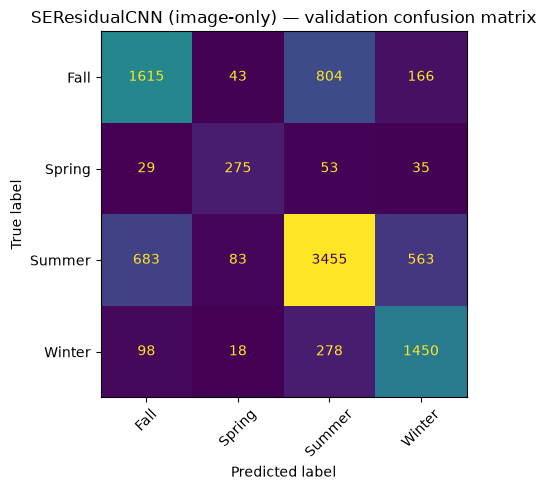

Saved to ../outputs/task2_models/seresidual_cnn_image_only.pt


In [16]:
# MODIFY: new. Image-only SE-Residual CNN -- directly comparable to
# ImprovedSmallCNN (image-only) above, same loaders and same fit() settings.
torch.manual_seed(RANDOM_STATE)
seres_img_only_model, seres_img_only_f1, seres_img_only_epoch = fit(
    ImageOnlyClassifier(SEResidualEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='SEResidualCNN (image-only)')
results['SEResidualCNN (image-only)'] = (seres_img_only_f1, seres_img_only_epoch)

seres_img_only_train_f1 = evaluate(seres_img_only_model, image_train_loader)

seres_img_only_model.eval()
seres_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        preds = seres_img_only_model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()
        seres_img_only_val_preds.extend(preds)
seres_img_only_val_preds = np.array(seres_img_only_val_preds)
seres_img_only_val_f1 = f1_score(y_val, seres_img_only_val_preds, average='macro')

n_params = sum(p.numel() for p in seres_img_only_model.parameters())
print(f'SEResidualCNN (image only) -- train F1: {seres_img_only_train_f1:.4f}, '
      f'val F1: {seres_img_only_val_f1:.4f}, {n_params/1e6:.2f}M params\n')
print(classification_report(y_val, seres_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, seres_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('SEResidualCNN (image-only) — validation confusion matrix')
plt.tight_layout()
plt.show()

torch.save({
    'model_state_dict': seres_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': seres_img_only_val_f1,
}, OUTPUT_DIR / 'seresidual_cnn_image_only.pt')
print(f"Saved to {OUTPUT_DIR / 'seresidual_cnn_image_only.pt'}")


#### 2. Multi-input model training

MultiInput-ResNet18Pretrained 1/70 train:   0%|          | 0/453 [00:01<?, ?it/s]

MultiInput-ResNet18Pretrained 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7387 - val_loss: 0.6758 - train_f1: 0.6826 - val_f1: 0.7250 - lr: 3.00e-04


MultiInput-ResNet18Pretrained 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained 19/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 19/70 - train_loss: 0.0997 - val_loss: 0.7656 - train_f1: 0.9639 - val_f1: 0.8333 - lr: 9.37e-06


MultiInput-ResNet18Pretrained 20/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 20/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/70 - train_loss: 0.0957 - val_loss: 0.7618 - train_f1: 0.9668 - val_f1: 0.8350 - lr: 9.37e-06
Early stopping triggered at epoch 20 (best epoch was 5)


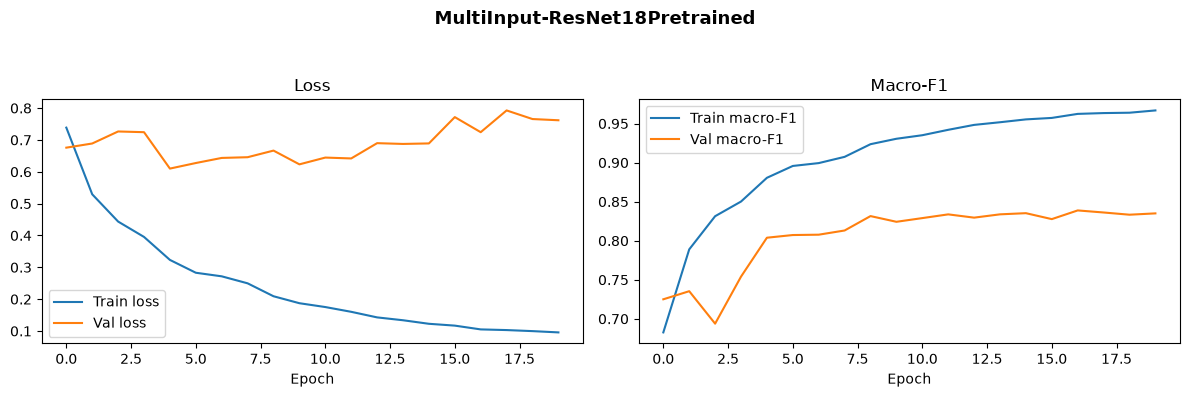

>>> Best checkpoint for MultiInput-ResNet18Pretrained: epoch 5  (val_loss=0.6101, val_f1=0.8039)


In [17]:
torch.manual_seed(RANDOM_STATE)
resnet_pretrained_model, resnet_pretrained_f1, resnet_pretrained_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader, val_loader, model_name='MultiInput-ResNet18Pretrained')
results['MultiInput-ResNet18Pretrained'] = (resnet_pretrained_f1, resnet_pretrained_epoch)


MultiInput-SmallCNN 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SmallCNN 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7991 - val_loss: 0.9209 - train_f1: 0.6528 - val_f1: 0.5994 - lr: 3.00e-04


MultiInput-SmallCNN 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SmallCNN 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-SmallCNN 32/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 32/70 - train_loss: 0.3569 - val_loss: 0.7037 - train_f1: 0.8713 - val_f1: 0.7926 - lr: 2.34e-06


MultiInput-SmallCNN 33/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SmallCNN 33/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 33/70 - train_loss: 0.3527 - val_loss: 0.6699 - train_f1: 0.8774 - val_f1: 0.7715 - lr: 2.34e-06
Early stopping triggered at epoch 33 (best epoch was 18)


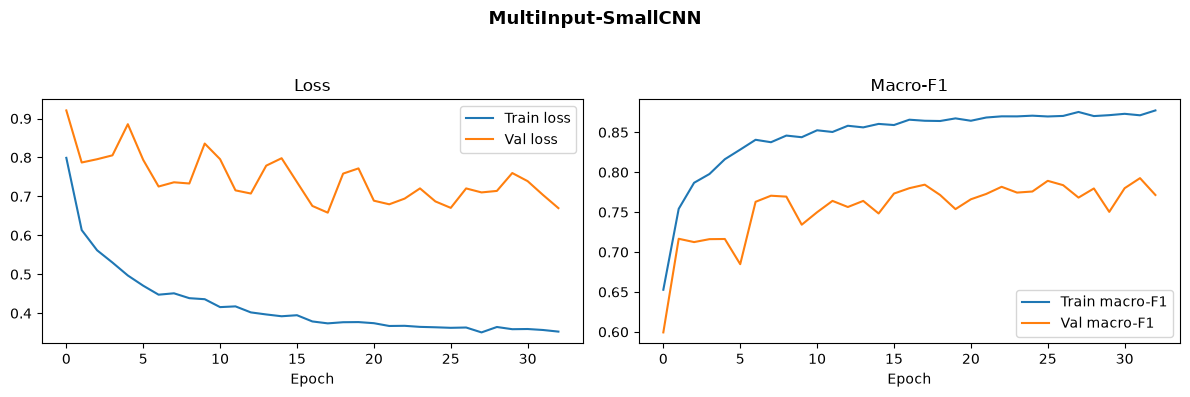

>>> Best checkpoint for MultiInput-SmallCNN: epoch 18  (val_loss=0.6583, val_f1=0.7844)


In [18]:
torch.manual_seed(RANDOM_STATE)
small_cnn_model, small_cnn_f1, small_cnn_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), SmallImageEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-SmallCNN')
results['MultiInput-SmallCNN'] = (small_cnn_f1, small_cnn_epoch)

MultiInput-ResNet18Scratch 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7797 - val_loss: 0.7587 - train_f1: 0.6560 - val_f1: 0.6802 - lr: 3.00e-04


MultiInput-ResNet18Scratch 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-ResNet18Scratch 29/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 29/70 - train_loss: 0.1085 - val_loss: 0.8621 - train_f1: 0.9608 - val_f1: 0.8268 - lr: 9.37e-06


MultiInput-ResNet18Scratch 30/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 30/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 30/70 - train_loss: 0.1071 - val_loss: 0.8028 - train_f1: 0.9613 - val_f1: 0.8274 - lr: 9.37e-06
Early stopping triggered at epoch 30 (best epoch was 15)


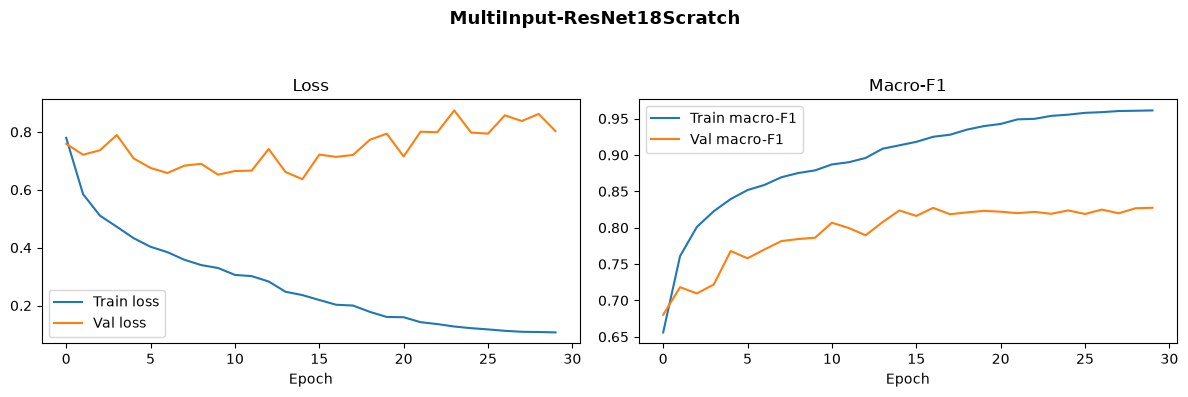

>>> Best checkpoint for MultiInput-ResNet18Scratch: epoch 15  (val_loss=0.6367, val_f1=0.8237)


In [19]:
torch.manual_seed(RANDOM_STATE)
resnet_scratch_model, resnet_scratch_f1, resnet_scratch_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), ResNet18Encoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-ResNet18Scratch')
results['MultiInput-ResNet18Scratch'] = (resnet_scratch_f1, resnet_scratch_epoch)

MultiInput-EfficientNet 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-EfficientNet 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8119 - val_loss: 0.8018 - train_f1: 0.6504 - val_f1: 0.6538 - lr: 3.00e-04


MultiInput-EfficientNet 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-EfficientNet 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-EfficientNet 21/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/70 - train_loss: 0.3135 - val_loss: 0.7300 - train_f1: 0.8861 - val_f1: 0.7765 - lr: 1.87e-05


MultiInput-EfficientNet 22/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-EfficientNet 22/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 22/70 - train_loss: 0.3125 - val_loss: 0.8022 - train_f1: 0.8875 - val_f1: 0.7938 - lr: 1.87e-05
Early stopping triggered at epoch 22 (best epoch was 7)


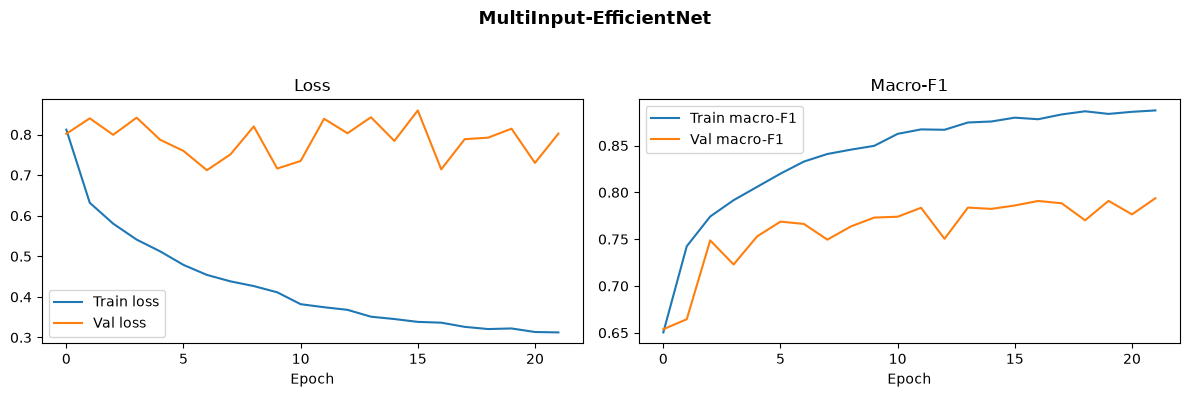

>>> Best checkpoint for MultiInput-EfficientNet: epoch 7  (val_loss=0.7121, val_f1=0.7663)


In [20]:
torch.manual_seed(RANDOM_STATE)
efficientNet_scratch_model, efficientNet_scratch_f1, efficientNet_scratch_epoch = fit(
    MultiInputNet(meta_train.shape[1], len(season_encoder.classes_), EfficientNetEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-EfficientNet')
results['MultiInput-EfficientNet'] = (efficientNet_scratch_f1, efficientNet_scratch_epoch)

MultiInput-ImprovedSmallCNN 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7904 - val_loss: 0.7794 - train_f1: 0.6577 - val_f1: 0.6676 - lr: 3.00e-04


MultiInput-ImprovedSmallCNN 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallCNN 42/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 42/70 - train_loss: 0.2669 - val_loss: 0.6353 - train_f1: 0.9023 - val_f1: 0.8171 - lr: 2.93e-07


MultiInput-ImprovedSmallCNN 43/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 43/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 43/70 - train_loss: 0.2672 - val_loss: 0.6879 - train_f1: 0.9036 - val_f1: 0.8121 - lr: 2.93e-07
Early stopping triggered at epoch 43 (best epoch was 28)


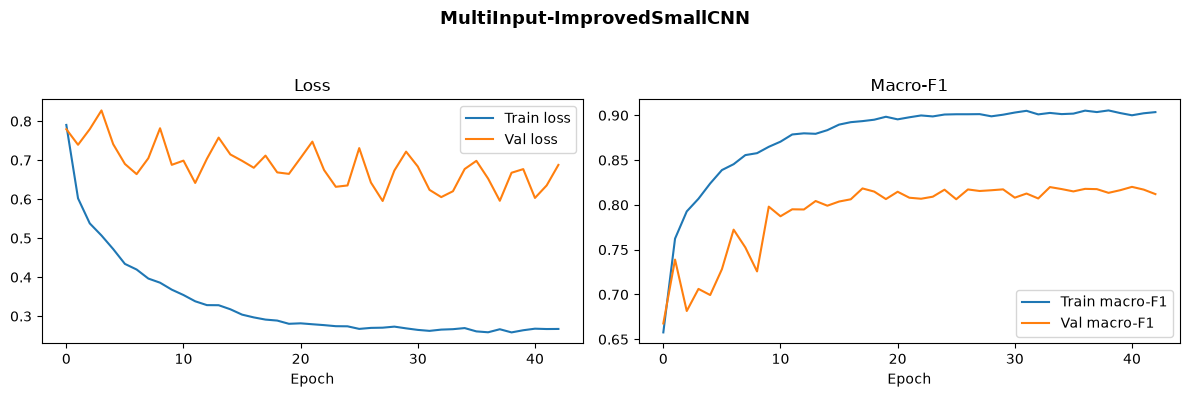

>>> Best checkpoint for MultiInput-ImprovedSmallCNN: epoch 28  (val_loss=0.5953, val_f1=0.8155)


In [21]:
torch.manual_seed(RANDOM_STATE)

improved_small_cnn_model, improved_small_cnn_f1, improved_small_cnn_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train.shape[1], 
        n_classes=len(season_encoder.classes_), 
        image_encoder=ImprovedSmallImageEncoder(out_dim=128)
    ).to(DEVICE), 
    train_loader, 
    val_loader,
    model_name='MultiInput-ImprovedSmallCNN'
)

results['MultiInput-ImprovedSmallCNN'] = (improved_small_cnn_f1, improved_small_cnn_epoch)

MultiInput-SEResidual 1/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SEResidual 1/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.7996 - val_loss: 0.8325 - train_f1: 0.6637 - val_f1: 0.6289 - lr: 3.00e-04


MultiInput-SEResidual 2/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SEResidual 2/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

MultiInput-SEResidual 33/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 33/70 - train_loss: 0.3197 - val_loss: 0.7287 - train_f1: 0.8823 - val_f1: 0.7929 - lr: 4.69e-06


MultiInput-SEResidual 34/70 train:   0%|          | 0/453 [00:00<?, ?it/s]

MultiInput-SEResidual 34/70 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 34/70 - train_loss: 0.3170 - val_loss: 0.7813 - train_f1: 0.8854 - val_f1: 0.7867 - lr: 4.69e-06
Early stopping triggered at epoch 34 (best epoch was 19)


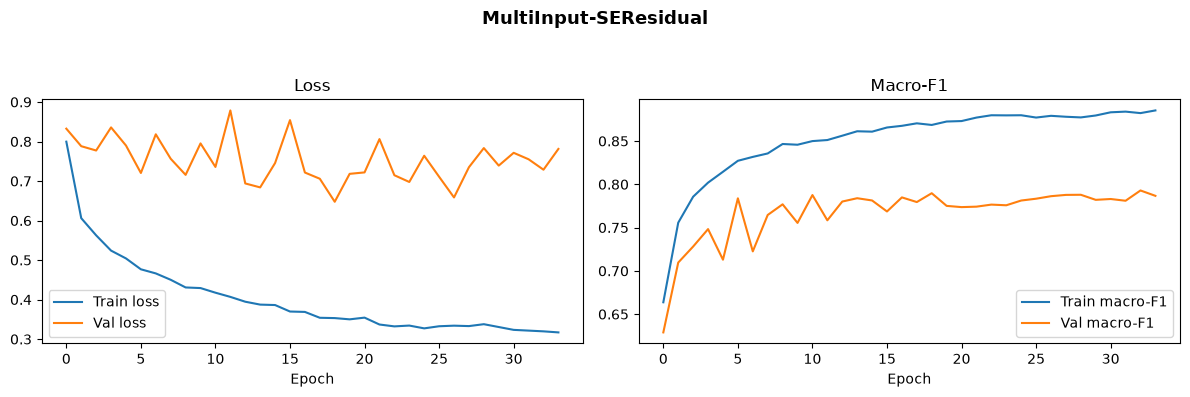

>>> Best checkpoint for MultiInput-SEResidual: epoch 19  (val_loss=0.6476, val_f1=0.7897)


In [22]:
# MODIFY: new. Multi-input variant on the SE-Residual encoder, so the fusion
# comparison covers the strongest from-scratch encoder too.
torch.manual_seed(RANDOM_STATE)
seres_multi_model, seres_multi_f1, seres_multi_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train.shape[1],
        n_classes=len(season_encoder.classes_),
        image_encoder=SEResidualEncoder(out_dim=128)
    ).to(DEVICE),
    train_loader,
    val_loader,
    model_name='MultiInput-SEResidual'
)
results['MultiInput-SEResidual'] = (seres_multi_f1, seres_multi_epoch)


In [23]:
PRETRAINED_MODELS = {'ResNet18 (pretrained)', 'MobileNetV3-Small (pretrained)', 'MultiInput-ResNet18Pretrained'}
saveable_results = {k: v for k, v in results.items() if k not in PRETRAINED_MODELS}

best_name = max(saveable_results, key=lambda k: saveable_results[k][0])
best_f1, best_epoch_num = saveable_results[best_name]

print('=== Early-stopping checkpoint summary ===')
for name, (f1, epoch) in sorted(results.items(), key=lambda kv: -kv[1][0]):
    if name == best_name:
        marker = '  <-- best (saveable)'
    elif name in PRETRAINED_MODELS:
        marker = '  (pretrained -- excluded from saving)'
    else:
        marker = ''
    print(f'{name:35s}  val_f1={f1:.4f}  (best epoch: {epoch}){marker}')

print(f'\nBest performing SAVEABLE model: {best_name} (val_f1={best_f1:.4f} at epoch {best_epoch_num})')

=== Early-stopping checkpoint summary ===
MultiInput-ResNet18Scratch           val_f1=0.8237  (best epoch: 15)  <-- best (saveable)
MultiInput-ImprovedSmallCNN          val_f1=0.8155  (best epoch: 28)
MultiInput-ResNet18Pretrained        val_f1=0.8039  (best epoch: 5)  (pretrained -- excluded from saving)
MultiInput-SEResidual                val_f1=0.7897  (best epoch: 19)
MultiInput-SmallCNN                  val_f1=0.7844  (best epoch: 18)
MultiInput-EfficientNet              val_f1=0.7663  (best epoch: 7)
ResNet18 (pretrained)                val_f1=0.7196  (best epoch: 9)  (pretrained -- excluded from saving)
ImprovedSmallCNN (image-only)        val_f1=0.7114  (best epoch: 19)
SEResidualCNN (image-only)           val_f1=0.6923  (best epoch: 18)

Best performing SAVEABLE model: MultiInput-ResNet18Scratch (val_f1=0.8237 at epoch 15)


In [24]:
model_lookup = {
    'ResNet18 (pretrained)': resnet_model,
    'MultiInput-EfficientNet': efficientNet_scratch_model,
    'MultiInput-SmallCNN': small_cnn_model,
    'MultiInput-ResNet18Scratch': resnet_scratch_model,
    'MultiInput-ResNet18Pretrained': resnet_pretrained_model,
    'MultiInput-ImprovedSmallCNN': improved_small_cnn_model,
    # MODIFY: new entries for the from-scratch SE-Residual models.
    'SEResidualCNN (image-only)': seres_img_only_model,
    'MultiInput-SEResidual': seres_multi_model,
}


In [25]:
# Evaluate both splits and compare all models
multi_train_loader = DataLoader(
    MultiInputDataset(task2_train, meta_train, y_train, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

multi_val_loader = DataLoader(
    MultiInputDataset(task2_val, meta_val, y_val, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

scores = pd.DataFrame({
    'Train F1': [
        logreg_train_f1,
        resnet_train_f1,
        improved_small_cnn_img_only_train_f1,
        seres_img_only_train_f1,          # MODIFY: new row
        evaluate(seres_multi_model, multi_train_loader),   # MODIFY: new row
        evaluate(efficientNet_scratch_model, multi_train_loader),
        evaluate(small_cnn_model, multi_train_loader),
        evaluate(improved_small_cnn_model, multi_train_loader),
        evaluate(resnet_scratch_model, multi_train_loader),
        evaluate(resnet_pretrained_model, multi_train_loader),
    ],
    'Validation F1': [
        logreg_val_f1,
        resnet_val_f1,
        improved_small_cnn_img_only_val_f1,
        seres_img_only_val_f1,            # MODIFY: new row
        evaluate(seres_multi_model, multi_val_loader),     # MODIFY: new row
        evaluate(efficientNet_scratch_model, multi_val_loader),
        evaluate(small_cnn_model, multi_val_loader),
        evaluate(improved_small_cnn_model, multi_val_loader),
        evaluate(resnet_scratch_model, multi_val_loader),
        evaluate(resnet_pretrained_model, multi_val_loader),
    ]
# MODIFY: this raised "Length of values does not match length of index" -- each
# column supplied 8 scores but only 7 labels were listed, because
# 'ImprovedSmallCNN (image-only)' was missing. The order was also wrong: the labels
# listed EfficientNet third while the values had improved_small_cnn_img_only there.
# Both fixed; the labels below now match the value order exactly, row for row.
}, index=[
    'Logistic Regression',
    'ResNet18 (pretrained)',
    'ImprovedSmallCNN (image-only)',
    'SEResidualCNN (image-only)',
    'MultiInput-SEResidual',
    'MultiInput-EfficientNet',
    'MultiInput-SmallCNN',
    'MultiInput-ImprovedSmallCNN',
    'MultiInput-ResNet18Scratch',
    'MultiInput-ResNet18Pretrained',
])

display(scores.round(4))

,Train F1,Validation F1
Logistic Regression,0.7322,0.7357
ResNet18 (pretrained),0.8367,0.7196
ImprovedSmallCNN (image-only),0.8307,0.7114
SEResidualCNN (image-only),0.7810,0.6923
MultiInput-SEResidual,0.8201,0.7897
MultiInput-EfficientNet,0.7862,0.7663
MultiInput-SmallCNN,0.8072,0.7844
MultiInput-ImprovedSmallCNN,0.8769,0.8155
MultiInput-ResNet18Scratch,0.9004,0.8237
MultiInput-ResNet18Pretrained,0.8663,0.8039


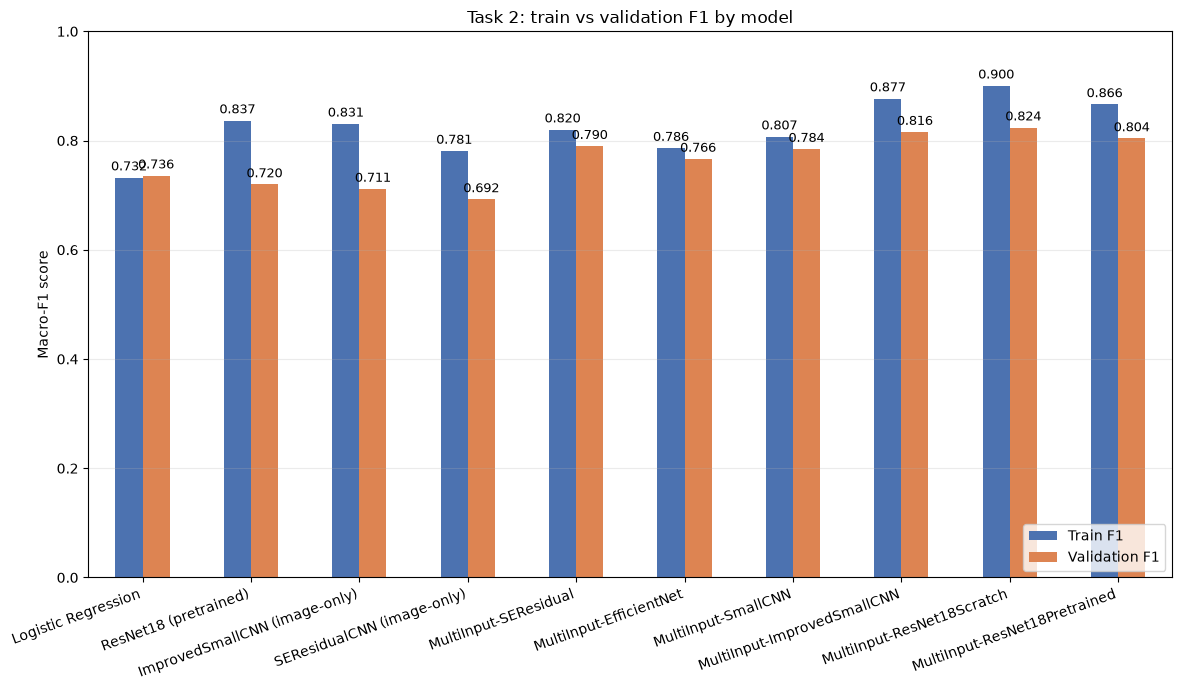

In [26]:
ax = scores.plot(kind='bar', figsize=(12, 7), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score'); plt.title('Task 2: train vs validation F1 by model'); plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

### Saving the best multi-input model

**MODIFY — this section is new.** The comparison above ended by *printing* the best model's name; nothing wrote it to disk, so every trained multi-input model was lost on kernel restart. The best from-scratch multi-input model is selected on validation macro-F1 and saved here, alongside the config needed to rebuild the architecture.

Pretrained variants stay excluded from selection, matching the rule already applied in the checkpoint summary: the assignment allows them for comparison only. Note this model still cannot run on `styles_prediction.csv` — that file carries no metadata, which is why the image-only models are saved separately.

In [27]:
# MODIFY: new. Selects and saves the best FROM-SCRATCH multi-input model.
multi_input_candidates = {
    'MultiInput-SmallCNN': (small_cnn_model, small_cnn_f1, SmallImageEncoder),
    'MultiInput-ResNet18Scratch': (resnet_scratch_model, resnet_scratch_f1, ResNet18Encoder),
    'MultiInput-EfficientNet': (efficientNet_scratch_model, efficientNet_scratch_f1, EfficientNetEncoder),
    'MultiInput-ImprovedSmallCNN': (improved_small_cnn_model, improved_small_cnn_f1, ImprovedSmallImageEncoder),
    'MultiInput-SEResidual': (seres_multi_model, seres_multi_f1, SEResidualEncoder),
}

print('Multi-input candidates (validation macro-F1, from-scratch only):')
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f'  {name:32s} {f1_val:.4f}')

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_encoder_cls = multi_input_candidates[best_multi_name]
print(f'\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})')
print(f'>>> For reference, the pretrained variant scored '
      f'{resnet_pretrained_f1:.4f} -- excluded from selection by the assignment rule.')

torch.save({
    'model_state_dict': best_multi_model.state_dict(),
    'model_name': best_multi_name,
    'image_encoder': best_multi_encoder_cls.__name__,
    'metadata_dim': int(meta_train.shape[1]),
    'n_classes': int(len(season_encoder.classes_)),
    'out_dim': 128,
    'val_f1': float(best_multi_f1),
    'pretrained': False,
}, OUTPUT_DIR / 'best_multiinput_task2.pt')

joblib.dump(meta_preprocessor, OUTPUT_DIR / 'meta_preprocessor_task2.joblib')

# Reload check -- confirms the checkpoint reconstructs into a working model.
ckpt = torch.load(OUTPUT_DIR / 'best_multiinput_task2.pt', map_location=DEVICE)
reloaded = MultiInputNet(ckpt['metadata_dim'], ckpt['n_classes'],
                         best_multi_encoder_cls(out_dim=ckpt['out_dim'])).to(DEVICE)
reloaded.load_state_dict(ckpt['model_state_dict'])
print('Reload check: state dict loads cleanly into a fresh model.')
print('Saved:', OUTPUT_DIR / 'best_multiinput_task2.pt')
print('Saved:', OUTPUT_DIR / 'meta_preprocessor_task2.joblib',
      '(needed to rebuild the metadata vector at inference time)')


Multi-input candidates (validation macro-F1, from-scratch only):
  MultiInput-ResNet18Scratch       0.8237
  MultiInput-ImprovedSmallCNN      0.8155
  MultiInput-SEResidual            0.7897
  MultiInput-SmallCNN              0.7844
  MultiInput-EfficientNet          0.7663

>>> Best multi-input model: MultiInput-ResNet18Scratch (val macro-F1 = 0.8237)
>>> For reference, the pretrained variant scored 0.8039 -- excluded from selection by the assignment rule.
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task2_models/best_multiinput_task2.pt
Saved: ../outputs/task2_models/meta_preprocessor_task2.joblib (needed to rebuild the metadata vector at inference time)
